# Lesson 1.7 — 1D Diffusion Equation

## The Heat Conduction Analogy

Hold a metal rod with one end in a flame. Heat spreads from the hot end toward the cold end —
not at a fixed speed like advection, but by smoothing out gradients. Sharp temperature differences
get erased over time. This is **diffusion**.

The mathematical description (Fourier's law → conservation of energy):

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

where $\alpha$ is the diffusivity (thermal diffusivity, viscosity, mass diffusivity — same equation,
different physics). The second derivative smooths: if $u'' > 0$ (concave up), $u$ increases; if
$u'' < 0$ (concave down), $u$ decreases. Mountains get shorter, valleys fill up.

---

## Explicit (FTCS) Scheme

Forward in time, central in space:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \alpha \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$$

$$u_i^{n+1} = u_i^n + r(u_{i+1}^n - 2u_i^n + u_{i-1}^n)$$

where $r = \alpha \Delta t / \Delta x^2$ is the **diffusion number** (analogous to CFL).

**Stability condition**: $r \leq \frac{1}{2}$ (in 1D), $r \leq \frac{1}{4}$ (in 2D).

This is far more restrictive than the CFL condition for advection!
Halving the grid spacing requires 4× more time steps (since $r \propto \Delta t / \Delta x^2$).

---

## Implicit (BTCS) Scheme

Backward in time, central in space:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \alpha \frac{u_{i+1}^{n+1} - 2u_i^{n+1} + u_{i-1}^{n+1}}{\Delta x^2}$$

Rearranging gives a tridiagonal system:

$$-r u_{i-1}^{n+1} + (1 + 2r) u_i^{n+1} - r u_{i+1}^{n+1} = u_i^n$$

This is **unconditionally stable** — any $\Delta t$ is permitted. The cost: you must solve
a linear system at each time step. But with a tridiagonal solver it's $O(N)$ — fast.

---

## Why Implicit Schemes Dominate CFD

In real CFD, viscous terms (which are diffusion) would force an explicit solver to use
extremely small time steps near walls (where $\Delta x$ is tiny). Implicit schemes are
essential for efficiency. This is why the SIMPLE algorithm (Module 02) uses implicit
pressure-velocity coupling.


Explicit: dt = 0.006409s, nt = 312 steps
Implicit: dt = 0.100000s, nt = 20 steps  (16x fewer!)


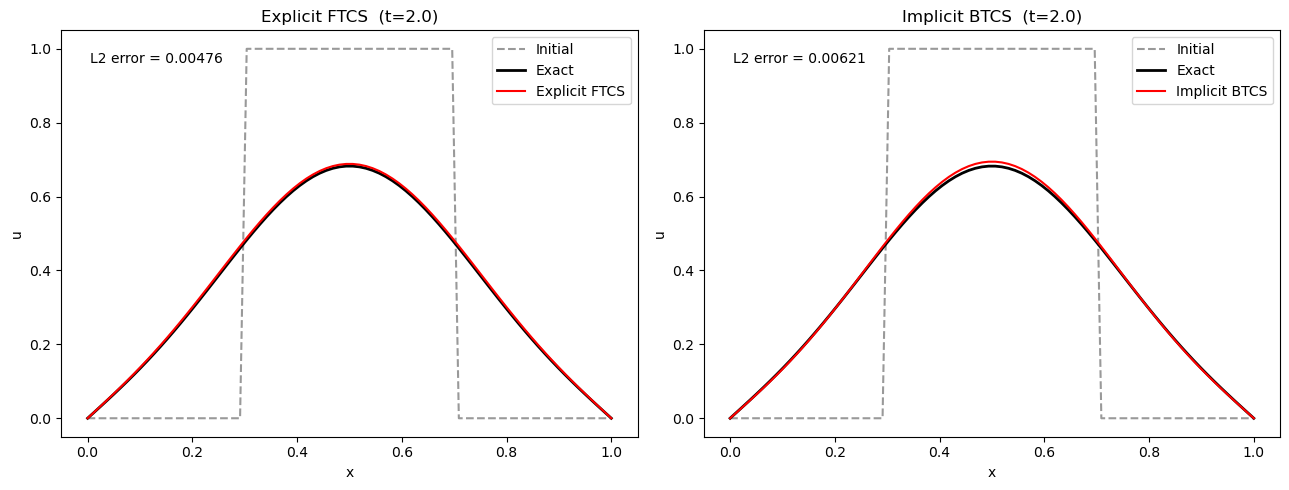

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def diffuse_explicit(u0, alpha, dx, dt, nt):
    """FTCS explicit diffusion."""
    u = u0.copy()
    r = alpha * dt / dx**2
    for _ in range(nt):
        u[1:-1] += r * (u[2:] - 2*u[1:-1] + u[:-2])
        # Dirichlet BC: u[0]=u[-1]=0 (walls held at zero)
    return u

def diffuse_implicit(u0, alpha, dx, dt, nt):
    """BTCS implicit diffusion — solve tridiagonal at each step."""
    u = u0.copy()
    N = len(u)
    r = alpha * dt / dx**2
    
    # Build tridiagonal system in banded form (for solve_banded)
    ab = np.zeros((3, N-2))
    ab[0, 1:]  = -r          # super-diagonal
    ab[1, :]   = 1 + 2*r     # main diagonal
    ab[2, :-1] = -r          # sub-diagonal
    
    for _ in range(nt):
        rhs = u[1:-1].copy()
        # Dirichlet BCs: add boundary contributions to rhs
        rhs[0]  += r * u[0]
        rhs[-1] += r * u[-1]
        u[1:-1] = solve_banded((1, 1), ab, rhs)
    return u

# Setup
N     = 80
L     = 1.0
dx    = L / (N - 1)
x     = np.linspace(0, L, N)
alpha = 0.01
T     = 2.0

# Initial condition: top-hat
u0 = np.zeros(N)
u0[(x >= 0.3) & (x <= 0.7)] = 1.0
u0[0] = u0[-1] = 0.0  # Dirichlet BCs

# Exact solution (Fourier series, first 20 terms)
def exact_diffusion(x, T, alpha, n_terms=20):
    u = np.zeros_like(x)
    for n in range(1, n_terms + 1):
        # Fourier coefficient for top-hat on [0.3, 0.7]
        bn = (2.0/np.pi/n) * (np.cos(n*np.pi*0.3) - np.cos(n*np.pi*0.7))
        u += bn * np.exp(-alpha * (n*np.pi)**2 * T) * np.sin(n*np.pi*x)
    return u

u_exact = exact_diffusion(x, T, alpha)

# Explicit: must use small dt (stability: r <= 0.5)
dt_expl = 0.4 * dx**2 / alpha
nt_expl = int(T / dt_expl)
u_expl  = diffuse_explicit(u0, alpha, dx, dt_expl, nt_expl)

# Implicit: can use large dt
dt_impl = 0.1  # 100x larger than explicit limit!
nt_impl = int(T / dt_impl)
u_impl  = diffuse_implicit(u0, alpha, dx, dt_impl, nt_impl)

print(f"Explicit: dt = {dt_expl:.6f}s, nt = {nt_expl} steps")
print(f"Implicit: dt = {dt_impl:.6f}s, nt = {nt_impl} steps  ({nt_expl/nt_impl:.0f}x fewer!)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, u_num, label in zip(axes,
                             [u_expl, u_impl],
                             ['Explicit FTCS', 'Implicit BTCS']):
    ax.plot(x, u0,     'k--', alpha=0.4, label='Initial')
    ax.plot(x, u_exact,'k-',  linewidth=2, label='Exact')
    ax.plot(x, u_num,  'r-',  linewidth=1.5, label=label)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.set_title(f'{label}  (t={T})')
    ax.legend()
    l2 = np.sqrt(np.mean((u_num - u_exact)**2))
    ax.text(0.05, 0.92, f'L2 error = {l2:.5f}', transform=ax.transAxes)

plt.tight_layout()
plt.show()

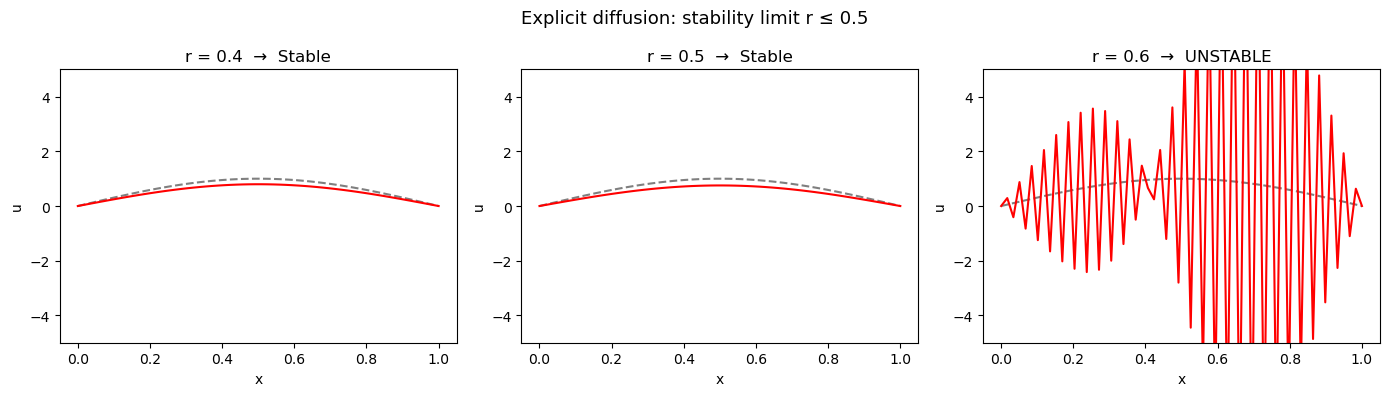

In [2]:
# Show explicit instability when r > 0.5
N  = 60
dx = 1.0 / (N - 1)
x  = np.linspace(0, 1, N)
alpha = 0.01
u0 = np.sin(np.pi * x)  # clean initial condition
u0[0] = u0[-1] = 0.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, r in zip(axes, [0.4, 0.5, 0.6]):
    dt = r * dx**2 / alpha
    u  = u0.copy()
    blown = False
    for _ in range(200):
        u[1:-1] += r * (u[2:] - 2*u[1:-1] + u[:-2])
        if np.max(np.abs(u)) > 10:
            blown = True
            break
    ax.plot(x, u0, 'k--', alpha=0.5, label='Initial')
    ax.plot(x, u,  'r-', linewidth=1.5)
    stability = 'UNSTABLE' if blown else 'Stable'
    ax.set_title(f'r = {r}  →  {stability}')
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.set_ylim(-5, 5)

plt.suptitle('Explicit diffusion: stability limit r ≤ 0.5', fontsize=13)
plt.tight_layout()
plt.show()

## Key Takeaways

- The diffusion equation $\partial_t u = \alpha \partial_{xx} u$ smooths gradients over time.
- Explicit FTCS: simple to code but stability requires $r = \alpha \Delta t / \Delta x^2 \leq 1/2$.
- This limit is harsh: refining the mesh 2× forces 4× more time steps.
- Implicit BTCS: unconditionally stable — use any time step. Cost: one tridiagonal solve per step ($O(N)$).
- In 2D N-S (viscous terms), this is why SIMPLE uses implicit discretization.

---

**Next**: Lesson 1.8 — 1D Burgers' Equation: introducing nonlinearity and shock formation.
